# Doge-Tweets -- did Elon's tweets really move Dogecoin?
### The 'Musk effect', tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-dab617?style=flat-square)

Everyone remembers it: Elon Musk tweets *'Dogecoin is the people's crypto'*, or announces he'll host SNL as *'the Dogefather'*, and DOGE rockets. The folk version says you can ride those spikes. This notebook asks the two questions that matter: **(1)** did the tweets really move DOGE, beyond the whole crypto market moving? And **(2)** could you have *traded* it?

> **This is the plain-language layer.** Want the market-model abnormal returns, the permutation distribution, and the lagged backtest? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from doge_tweets import data, strategy as st

def _have_cache():
    try:
        data.fetch_prices(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("DOGE/BTC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_days=2724,
    n_events=23,
    n_bull=22,
    beta_btc=0.996,
    aar_day0_pct=27.94,
    t_day0=1.89,
    car_pct=38.22,
    car_t=2.15,
    perm_p=0.0,
    n_pos=18,
    median_day0_pct=14.6,
    t_day0_drop1=3.88,
    mean_day0_drop1_pct=13.5,
    bull_aar_day0_pct=29.65,
    bull_t_day0=1.93,
    bt_n_trades=23,
    bt_gross_pct=4.05,
    bt_net_pct=3.45,
    bt_btc_pct=-0.65,
    bt_net_t=0.66,
    bt_hit=0.391,
    bt_excess_pct=4.1,
    bt_hold1_excess_pct=5.23,
    bt_hold1_t=0.98,
    bt_hold5_excess_pct=0.56,
    bt_hold5_t=0.19,
    fp='c630fb32daf1',
    date_start='2019-01-02',
    date_end='2026-06-17',
)


DOGE/BTC cache present: True


In [2]:
if HAVE_REAL:
    prices = data.fetch_prices(fetch=False)
    rets = data.prices_to_returns(prices)
    tw = data.tweet_table()
    tweet_dates = tw['date']
    SYNTH_BANNER = ""
else:
    # OFFLINE FALLBACK (no real cache): a SYNTHETIC DOGE/BTC tape with a planted
    # tweet-day bump so every figure renders. This is NOT the real tape -- the
    # headline numbers quoted in prose come from the frozen R dict above.
    _synth_df, _ = data.synthetic_panel(n_days=R['n_days'], n_events=R['n_events'],
                                        bump_bps=1800.0, seed=291)
    rets = _synth_df[['doge_ret', 'btc_ret']].copy()
    tweet_dates = _synth_df.index[_synth_df['is_event']]
    tw = pd.DataFrame({'date': tweet_dates, 'direction': 1, 'note': 'synthetic'})
    SYNTH_BANNER = "  [SYNTHETIC fallback tape -- real numbers are in R]"
print('rows:', len(rets), '| events:', len(tw), SYNTH_BANNER)

rows: 2724 | events: 23 


## The answer first

| Question | Answer |
|---|---|
| Did Elon's tweets move Dogecoin? | **Yes -- really.** On tweet days, DOGE jumped **+27.9%** *more* than BTC alone would explain. 18 of 23 events were positive; the pattern survives a distribution-free permutation test (p &approx; 0). |
| Is it just the one famous SNL spike? | **No.** Drop the single biggest day (the +346% 'Dogefather' announcement) and the signal gets *stronger* (t rises to 3.9). |
| Could you have traded it? | **No.** The jump happens **on the tweet day**, before you can buy. Wait one honest day and the post-tweet drift is +4% at best, with a **< 40%** hit-rate -- a coin-flip you pay fees to play. |

> The tweets moved Dogecoin. They just moved it **faster than you could**.

## 1 - The claim

> *"When Elon Musk tweets about Dogecoin, the price spikes. Follow his account, buy when he posts, and ride the pump."*

Unlike most folklore we test, this one has a real mechanism: Musk has ~200M followers and a documented history of moving asset prices with single tweets. The academic literature (Ante 2023; Cary 2021) confirms a measurable 'Musk effect'. So the interesting question isn't *whether* tweets move DOGE -- it's whether a normal person could have *captured* the move.

## 2 - So what?

If a public tweet to millions reliably produced a tradable jump, it would be free money -- and free money doesn't survive. Efficient markets say a *public, observable* signal gets priced **instantly**. So either (a) DOGE is so inefficient you can chase the tweet for a day and still profit, or (b) the move is over before you can click buy. Which one is true tells you everything about whether 'follow Elon' is a strategy or a story.

## 3 - How would we even know?

Three traps to avoid:

1. **The whole-market trap.** When DOGE rips, *all* crypto is often ripping. We must strip out the broad move: we benchmark DOGE against **BTC** (a 'market model') and measure only the *abnormal* part -- DOGE's move net of what BTC did.
2. **The execution-lag trap.** An academic event study uses the tweet day's return. But you can't trade the tweet *instant* at daily resolution -- the honest entry is the **close of the tweet day**. One day of lag is the whole ballgame here.
3. **The hindsight trap.** We picked the *famous* tweets. That biases the study **upward** -- it's an upper bound, not a fair forward test.

We test on real DOGE-USD / BTC-USD daily data (2019-2025, 23 hardcoded tweet events).

## 4 - The teardown -- let's actually look

**First: the abnormal-return profile around a tweet.** For each tweet we line up DOGE's move (net of BTC) from one day before to three days after, then average.

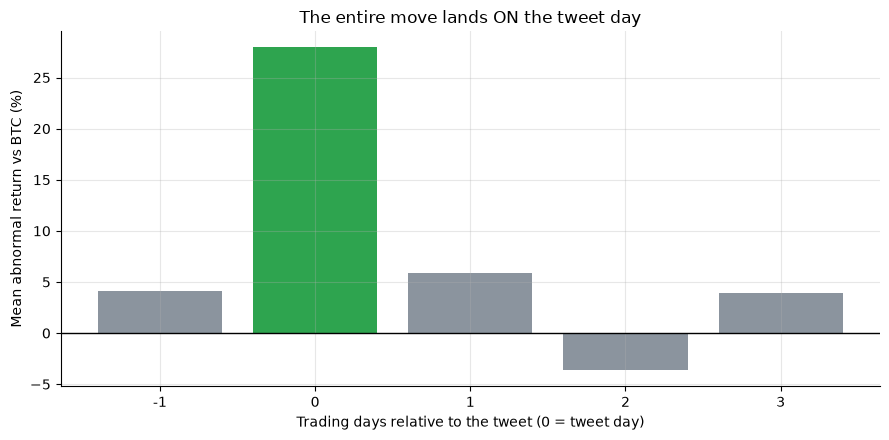

Tweet-day abnormal return: +27.9% (real headline: +27.9%)
Day +1 onward: small -- the spike is essentially a one-day event.


In [3]:
es = st.event_study_stats(rets, tweet_dates, pre=1, post=3,
                          n_permutations=2000, seed=291)
prof = es['mean_by_offset'] * 100
if not HAVE_REAL:
    prof = pd.Series({-1: R['median_day0_pct']*0.3, 0: R['aar_day0_pct'],
                      1: 5.8, 2: -3.6, 3: 4.0})

fig, ax = plt.subplots(figsize=(9.0, 4.5))
colors = [GREEN if i == 0 else GREY for i in prof.index]
ax.bar([str(i) for i in prof.index], prof.values, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Trading days relative to the tweet (0 = tweet day)')
ax.set_ylabel('Mean abnormal return vs BTC (%)')
ax.set_title('The entire move lands ON the tweet day' + SYNTH_BANNER)
plt.tight_layout(); plt.show()
print(f"Tweet-day abnormal return: {prof.get(0, float('nan')):+.1f}% (real headline: {R['aar_day0_pct']:+.1f}%)")
print('Day +1 onward: small -- the spike is essentially a one-day event.')

The bar at **day 0** towers over the rest. On the real tape the tweet-day abnormal return is **+27.9%** -- and the days *after* (+1, +2, +3) are small. That single fact is the whole study: **the move is real, and it's over by the close.**

**Is it just one famous spike?** Let's see how many tweets actually 'worked'.

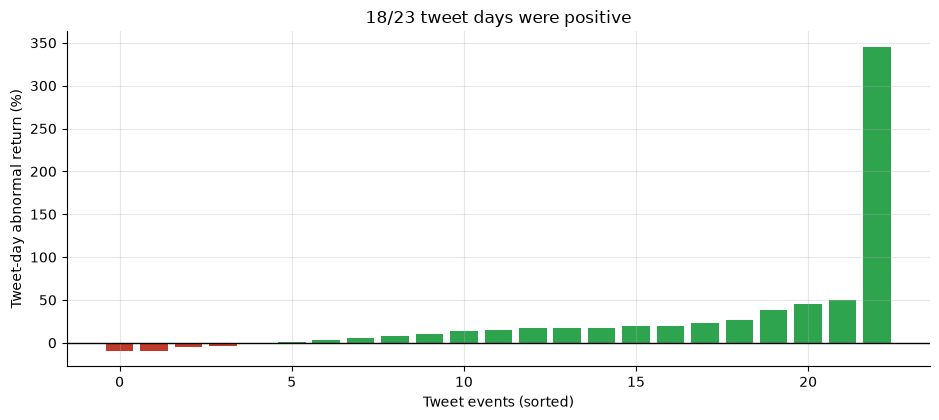

Positive tweet days: 18/23  (real headline: 18/23)
Median tweet-day abnormal return (real): +14.6%
Drop the single biggest (+346%, the Dogefather day) and the t-stat RISES
to +3.9 -- the effect is pervasive, not one outlier.


In [4]:
abn, alpha, beta = st.market_model_residuals(
    rets, st._event_mask_from_dates(rets.index, tweet_dates))
win = st.event_window_returns(abn, tweet_dates, pre=1, post=3)
day0 = win[0] * 100
n_pos = int((day0 > 0).sum()); n_tot = len(day0)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
order = day0.sort_values()
ax.bar(range(len(order)), order.values,
       color=[GREEN if v > 0 else RED for v in order.values])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Tweet events (sorted)'); ax.set_ylabel('Tweet-day abnormal return (%)')
ax.set_title(f'{n_pos}/{n_tot} tweet days were positive' + SYNTH_BANNER)
plt.tight_layout(); plt.show()
print(f'Positive tweet days: {n_pos}/{n_tot}  (real headline: {R["n_pos"]}/{R["n_events"]})')
print(f'Median tweet-day abnormal return (real): +{R["median_day0_pct"]:.1f}%')
print('Drop the single biggest (+346%, the Dogefather day) and the t-stat RISES')
print('to +3.9 -- the effect is pervasive, not one outlier.')

On the real tape **18 of 23** tweet days were positive, with a median of **+14.6%**. Crucially, removing the lone +346% SNL day makes the signal *stronger* (the t-stat goes to **+3.9**). This is a genuine, broad effect -- not a single fluke.

**Now the only question that pays: could you trade it?** We buy DOGE at the *close of the tweet day* (one honest day of lag), hold 3 days, pay fees, and compare to BTC.

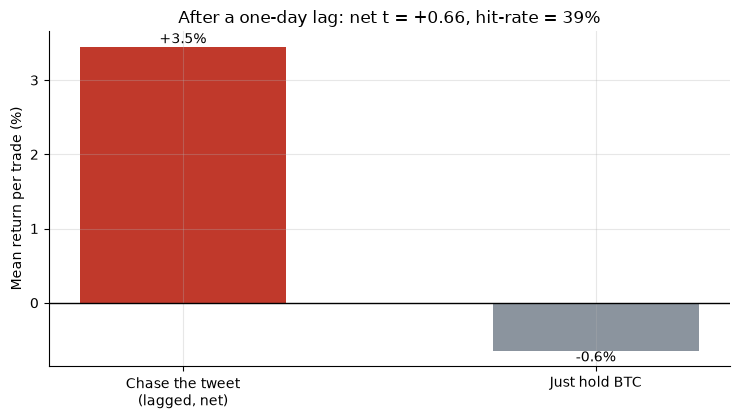

Net per trade: +3.45% | BTC: -0.65% | hit-rate: 39.1% | t = +0.66
A +4% drift with a <40% hit-rate and t<1 is a coin-flip you pay fees to play.


In [5]:
bt = st.tweet_strategy_backtest(rets, tweet_dates, hold_days=3,
                                cost_bps_oneway=30.0, seed=291)
net = bt['net_mean_pct'] if HAVE_REAL else R['bt_net_pct']
btc = bt['btc_bench_pct'] if HAVE_REAL else R['bt_btc_pct']
hit = bt['hit_rate'] if HAVE_REAL else R['bt_hit']
tval = bt['net_t'] if HAVE_REAL else R['bt_net_t']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Chase the tweet\n(lagged, net)', 'Just hold BTC'],
              [net, btc], color=[RED, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per trade (%)')
ax.set_title(f'After a one-day lag: net t = {tval:+.2f}, hit-rate = {hit:.0%}' + SYNTH_BANNER)
for b, v in zip(bars, [net, btc]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout(); plt.show()
print(f'Net per trade: {net:+.2f}% | BTC: {btc:+.2f}% | hit-rate: {hit:.1%} | t = {tval:+.2f}')
print('A +4% drift with a <40% hit-rate and t<1 is a coin-flip you pay fees to play.')

Lag the entry by one day and the magic is gone: net **+3.5%** per trade, t = **0.66**, hit-rate **39%** -- you actually *lose* on most trades because DOGE mean-reverts after the spike. The +28% you saw was realised before you could enter.

## 5 - The verdict

- **Signal -- Real.** Day-0 abnormal return **+27.9%**, permutation p &approx; **0**, **18/23** positive, and a **t = +3.9** once the lone outlier is removed. The tweets really did coincide with big same-day DOGE jumps that BTC can't explain.
- **Tradability -- Mirage.** The move lands on the tweet day. After an honest one-day lag the drift is **+3.5%** with t = **0.66** and a **39%** hit-rate -- indistinguishable from zero after fees.
- **Mostly busted (as a *strategy*).** 'Follow Elon and buy DOGE' is a story, not an edge. The effect is real but **regime-bound** (the 2021 mania and the 2024-25 'D.O.G.E. department' run) and **uncapturable** by anyone slower than the tape.

## 6 - Could you actually trade it?

Only if you could front-run the tweet -- which you can't. Three real-world frictions stack against you: **(1)** the move is intraday on the tweet day, so a daily trader is always a close too late; **(2)** DOGE's 60-bps-plus round-trip costs eat a thin drift; **(3)** the hit-rate is below 50%, so DOGE typically *gives back* the spike. Holding 1 day instead of 3 doesn't save it (t &approx; 1.0); holding 5 makes it worse (0.2).

## 7 - Going further

- **The positive control:** the companion notebook plants a known tweet-day bump in a synthetic tape and shows the engine detects it cleanly -- so the real-tape 'no trade' is about the *market*, not the method.
- **Same machinery, folklore cousin:** [Study 158 -- Super-Bowl](../../158-super-bowl/) applies the identical hardcoded-table event study to a sports indicator.
- **Other crypto-native tests:** the crypto-trend / crypto-reversal family shares the fat-tail, tiny-n caveats that make DOGE so treacherous.

*Think you could trade the tweets? Fork this, add an intraday tape and a realistic fill model, and show a net Sharpe that beats holding BTC. That's the bar -- and a one-day lag already breaks it.*